# Hotel Booking Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt



## Data Inspections

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Datasets/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [ ]:
df.describe(include="object").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [ ]:
df.duplicated().sum()

np.int64(31994)

In [ ]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


### The dataset contains 31,994 duplicate rows. Since there is no unique booking ID, these records may represent different bookings with the same information. Therefore, the duplicate rows were kept.


## Data Cleaning

In [ ]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)

In [ ]:
df.drop(columns="company", inplace=True)

Column contains more than 94% missing values.

In [ ]:
df["reservation_status_date"] = pd.to_datetime( df["reservation_status_date"])

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119390 non-null  float64

In [ ]:
df["children"] = df["children"].astype(int)

In [ ]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [ ]:
df[
    (df["adults"] == 0)
    & (df["children"] == 0)
    & (df["babies"] == 0)
].shape

(180, 31)

In [ ]:
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]

In [ ]:
df[df["adr"] > 1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,1,Non Refund,12.0,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [ ]:
df=df[df['adr']<1000]

In [ ]:
df[df["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [ ]:
df=df[df['adr']>0]

In [ ]:
df[df["adults"] > 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [ ]:
df[df["babies"] > 5]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
46619,City Hotel,0,37,2016,January,3,12,0,2,2,...,1,No Deposit,9.0,0,Transient,84.45,0,1,Check-Out,2016-01-14
78656,City Hotel,0,11,2015,October,42,11,2,1,1,...,1,No Deposit,95.0,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14


In [ ]:
df=df[df["babies"] < 5]

<Axes: xlabel='days_in_waiting_list'>

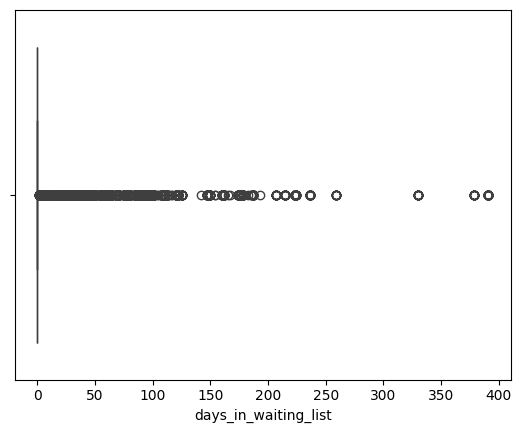

In [ ]:
sns.boxplot(x=df["days_in_waiting_list"])

In [ ]:
Q1 = df["days_in_waiting_list"].quantile(0.25)
Q3 = df["days_in_waiting_list"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(np.float64(0.0), np.float64(0.0))

Most bookings had no waiting time (0 days). Some bookings had long waiting periods, but these values are realistic and not considered data entry errors. Therefore, no outliers were removed from this column.
---



## Feature Engineering

In [ ]:
df["total_nights"] = (
    df["stays_in_weekend_nights"]
    + df["stays_in_week_nights"]
)

In [ ]:
df["family_size"] = (
    df["adults"]
    + df["children"]
    + df["babies"]
)

In [ ]:
df["is_family"] = (
    df["family_size"] > 1
).astype(int)

In [ ]:
df["has_previous_cancel"] = (
    df["previous_cancellations"] > 0
).astype(int)

In [ ]:
df["room_changed"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

## Data Visualization

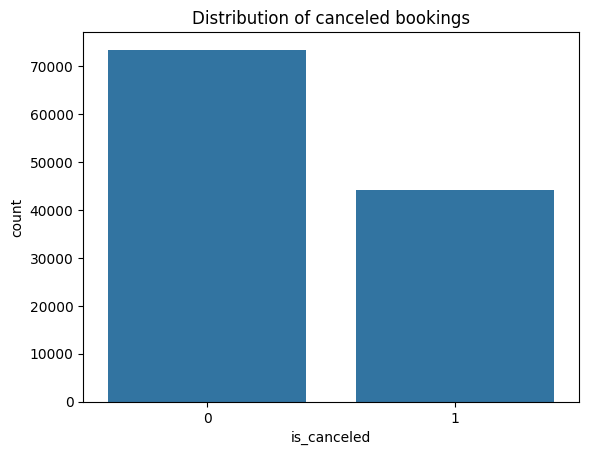

In [ ]:
plt.title("Distribution of canceled bookings")
sns.countplot(x='is_canceled', data=df)
plt.show()

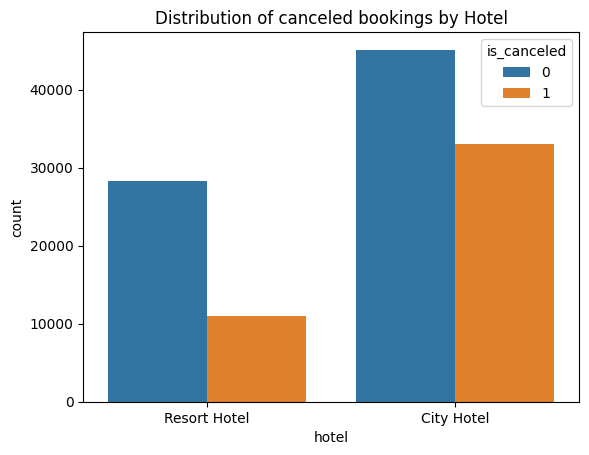

In [ ]:
plt.title("Distribution of canceled bookings by Hotel")
sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df
)
plt.show()

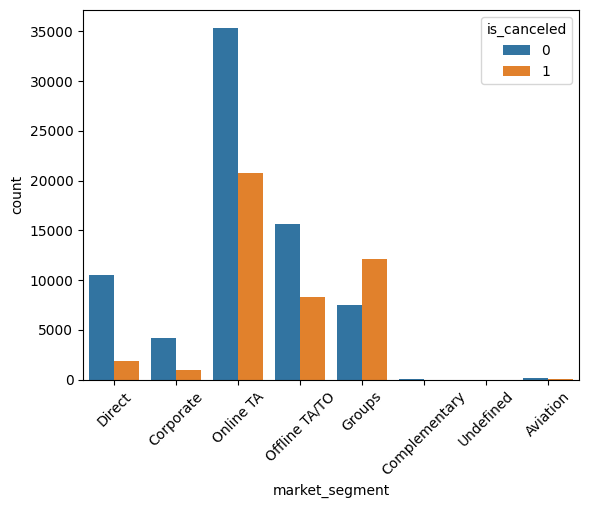

In [ ]:
sns.countplot(
    x='market_segment',
    hue='is_canceled',
    data=df
)
plt.xticks(rotation=45)

plt.show()

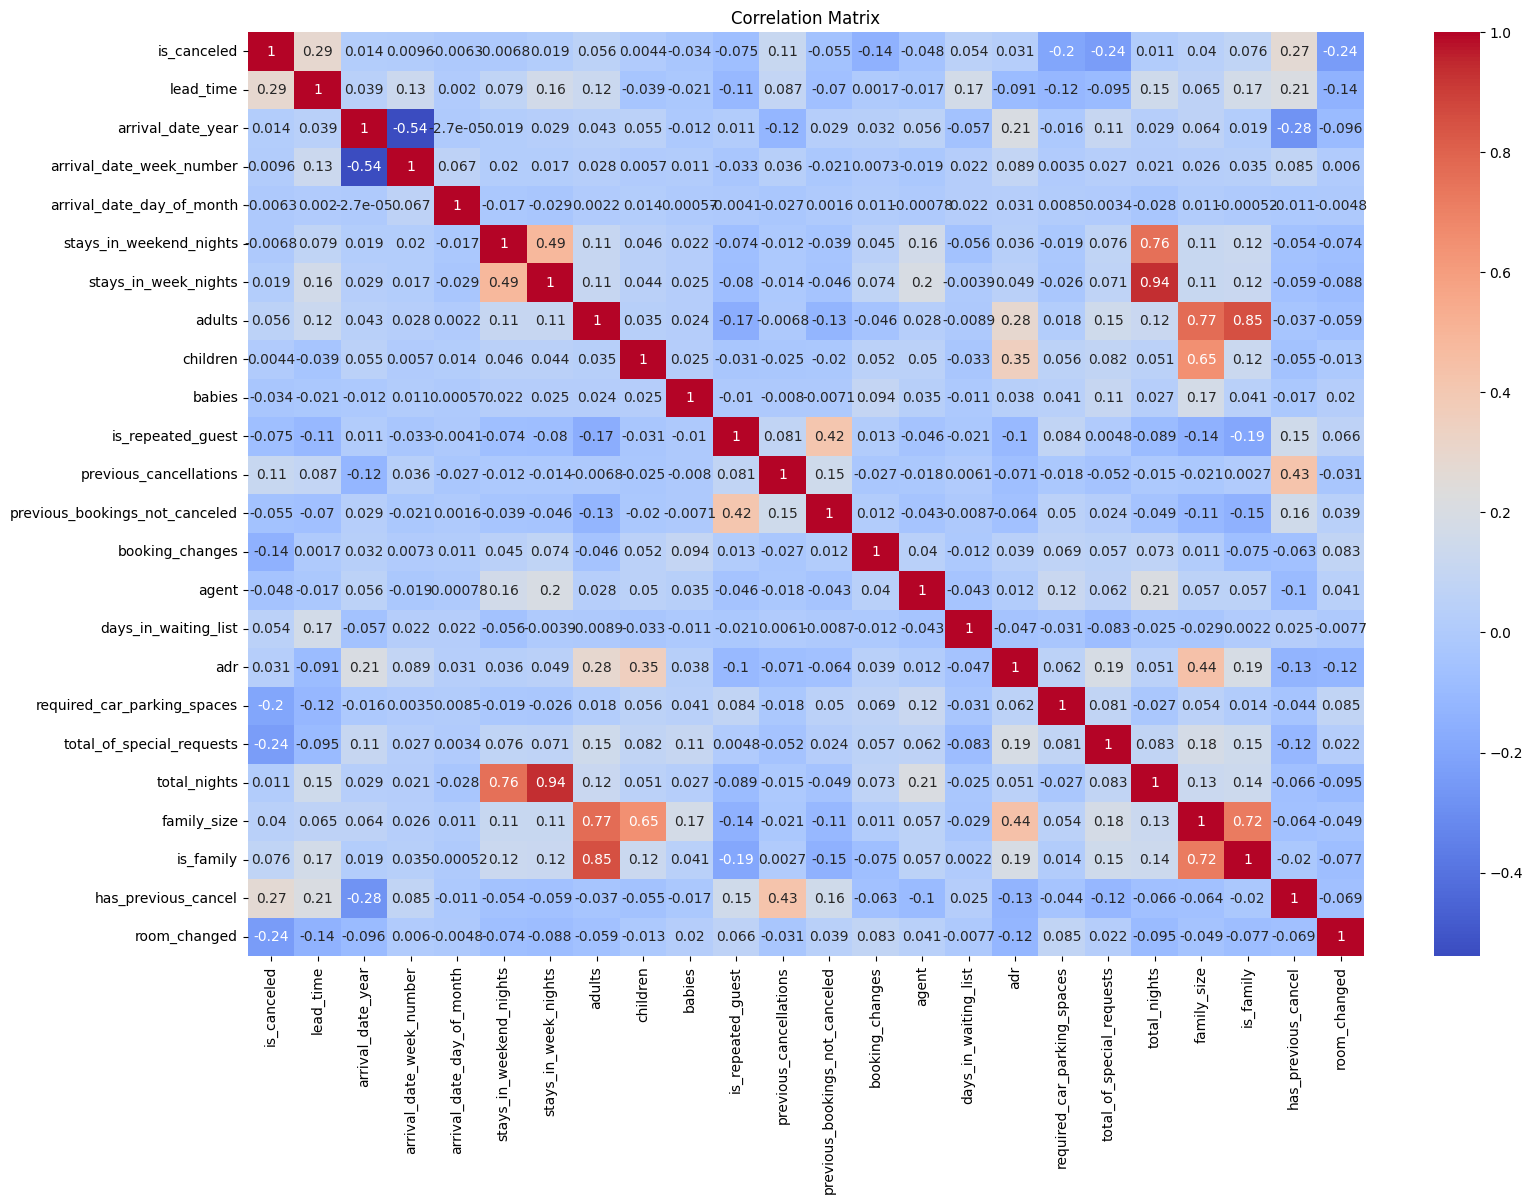

In [ ]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
print(
    df.corr(numeric_only=True)['is_canceled']
    .sort_values(key=abs, ascending=False).drop('is_canceled')
)


lead_time                         0.290515
has_previous_cancel               0.272308
room_changed                     -0.244273
total_of_special_requests        -0.237315
required_car_parking_spaces      -0.197518
booking_changes                  -0.144593
previous_cancellations            0.110668
is_family                         0.075777
is_repeated_guest                -0.074547
adults                            0.056266
previous_bookings_not_canceled   -0.054844
days_in_waiting_list              0.054103
agent                            -0.048291
family_size                       0.039962
babies                           -0.034094
adr                               0.030756
stays_in_week_nights              0.018949
arrival_date_year                 0.014127
total_nights                      0.011478
arrival_date_week_number          0.009601
stays_in_weekend_nights          -0.006820
arrival_date_day_of_month        -0.006327
children                          0.004376
Name: is_ca

In [ ]:
df.to_csv("cleaned_data.csv", index=False)

## Modeling

In [5]:
df=pd.read_csv("cleaned_data.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,family_size,is_family,has_previous_cancel,room_changed
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1,0,0,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1,0,0,0
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2,1,0,0
3,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2,1,0,0
4,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,107.0,0,0,Check-Out,2015-07-03,2,2,1,0,0


In [6]:
# remove column cause Data Leakege
df = df.drop(
    columns=[
        "reservation_status","reservation_status_date"])


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type"
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ])

In [9]:
from sklearn.ensemble import RandomForestClassifier


# Pipeline
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42,n_estimators=100))
])

# train
pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8968483816013628
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     14678
           1       0.90      0.82      0.86      8802

    accuracy                           0.90     23480
   macro avg       0.90      0.88      0.89     23480
weighted avg       0.90      0.90      0.90     23480



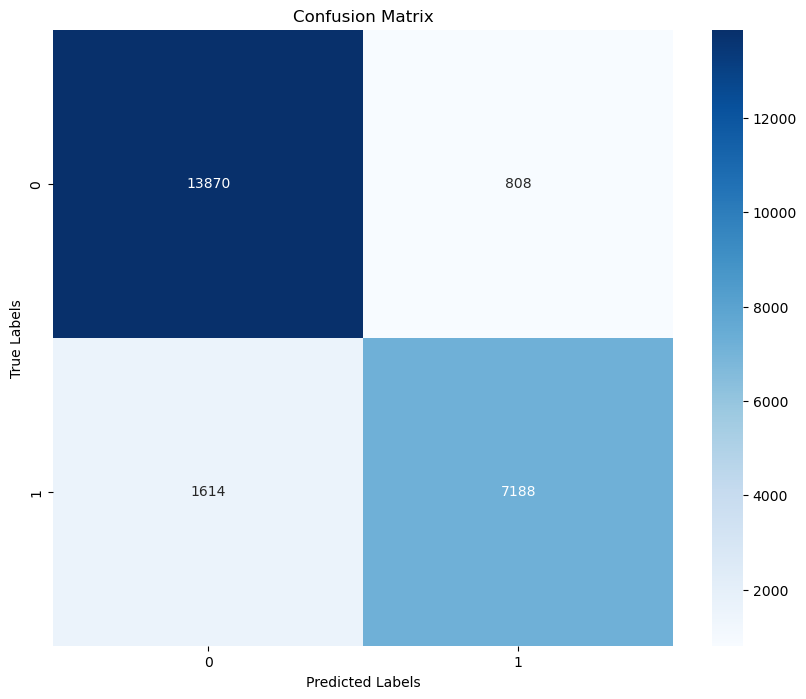

In [11]:
from sklearn.metrics import confusion_matrix 
con_matrix=confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(con_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression


# Pipeline
pipeline_lg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# train
pipeline_lg.fit(X_train, y_train)

y_pred_lg = pipeline_lg.predict(X_test)

In [11]:

print("Accuracy:", accuracy_score(y_test, y_pred_lg))
print(classification_report(y_test, y_pred_lg))

Accuracy: 0.8247444633730835
              precision    recall  f1-score   support

           0       0.83      0.91      0.87     14678
           1       0.82      0.68      0.74      8802

    accuracy                           0.82     23480
   macro avg       0.82      0.80      0.81     23480
weighted avg       0.82      0.82      0.82     23480



In [12]:
from sklearn.svm import SVC

# Pipeline
pipeline_sv = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",C=1.0,
        gamma="scale",
        random_state=42))
    ])

# Train
pipeline_sv.fit(X_train, y_train)

# Predict
y_pred_sv = pipeline_sv.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_sv))
print(classification_report(y_test, y_pred_sv))

Accuracy: 0.8641396933560477
              precision    recall  f1-score   support

           0       0.86      0.93      0.90     14678
           1       0.86      0.76      0.81      8802

    accuracy                           0.86     23480
   macro avg       0.86      0.84      0.85     23480
weighted avg       0.86      0.86      0.86     23480



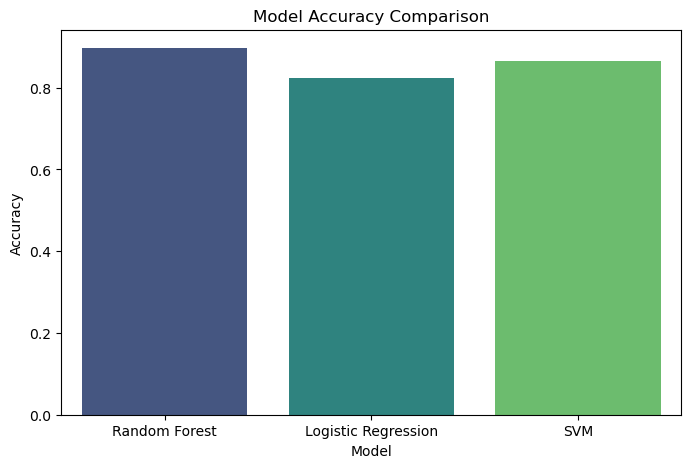

In [14]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression","SVM"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_lg), accuracy_score(y_test, y_pred_sv)]
})

plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results, palette="viridis", hue="Model", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

### best model is Random Forest with 89% accuracy

In [12]:
import joblib

joblib.dump(pipeline_rf, "hotel_model.pkl")

['hotel_model.pkl']